## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?

Both predict an outcome $y$ from features $X$. In regression the outcome is a number on a
continuous scale (price, temperature), and errors are measured by *how far off* the prediction is
(e.g. SSE). In classification the outcome is a category (mine type 1-5, spam/not spam), and a
prediction is simply right or wrong (accuracy, confusion table). For $k$-NN the only difference is
the last step: regression averages the neighbors' $y$ values; classification takes a
majority vote of the neighbors' labels.

2. What is a confusion table? What does it help us understand about a model's performance?

A cross-tabulation of actual labels (rows) against predicted labels (columns) on the test set.
The diagonal counts correct predictions; every off-diagonal cell is a specific kind of mistake
("actual 3, predicted 1"). It shows what a single accuracy number hides: which classes the model
handles well, which classes it confuses with each other, and whether its errors are costly.
(e.g. calling a real mine "no mine").

3. What does the SSE quantify about a particular model?

The sum of squared errors, $\text{SSE} = \sum_i (y_i - \hat y_i)^2$, measures the total squared
distance between actual and predicted values for a regression model. Lower is better. Squaring makes
errors positive and penalizes big misses much more than small ones. It is in squared units of $y$
and grows with sample size, so it is mainly useful for comparing models on the same data (e.g.
different $k$ on the same test set).

4. What are overfitting and underfitting? 

Overfitting: the model is too flexible and memorizes noise in the training data. It looks great on
training data and does poorly on new data.
Underfitting: the model is too rigid to capture the real pattern and does poorly everywhere.
($k = n$ predicts the most common class for every point, ignoring the features.)

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

If we judged $k$ on the same data we trained on, $k=1$ would always "win," because every point
finds itself. That rewards memorization. Holding out a test set simulates new, unseen data, so the
$k$ that does best there is the one that generalizes best, balancing over- and underfitting.


6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

A single label is simple, easy to act on, and easy to score (accuracy, confusion table). But it
hides uncertainty: a 2-1 neighbor vote and a 3-0 vote produce the same answer, and it silently uses
the most voted as the decision rule even when mistakes have very different costs.
Probabilities (e.g. 2/3 type 1, 1/3 type 3) convey confidence, let the user set thresholds that
match the costs ("only call it safe if P(no mine) > 0.95"), and can be combined with other evidence.
The downsides: they are harder for non-experts to interpret, they still require someone to make the
final decision, they can be poorly calibrated (with $k$-NN they are coarse, multiples of $1/k$), and
they need different evaluation tools.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.

I fit a k-NN model on the training set for every k from 1 to 100, measured accuracy on the test set, and kept the k with the highest accuracy. The best was k = 3, with 43.2% test accuracy. Very small k overfits to individual noisy points. Large k underfits, because it pulls in neighbors from other classes. The accuracy curve is jumpy since the test set is small: one prediction changes accuracy by about 0.6%.

4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?

The k = 3 model gets 43.2% of the test set right. That's about twice the 20% you'd get by random guessing, but still not reliable. It does best on anti-tank mines (type 2), getting 29 of 35 correct (83%), because their high voltage readings set them apart from the other types. It does reasonably well on "no mine" (type 1), with 24 of 36 correct (67%). It does poorly on the three anti-personnel types: 8 of 33 for type 3, 8 of 33 for type 4, and 4 of 32 for type 5. Their voltage readings overlap, so the model confuses them with each other and with "no mine." The most serious problem is that 40 real mines were labeled "no mine," which is the most dangerous mistake this model can make.

5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

This model should never be used on its own to decide that an area is safe. It labeled 40 of the 133 real mines in the test set (about 30%) as "no mine," and that mistake could cost lives. It works best as a screening tool. Its anti-tank predictions are fairly reliable, but every "no mine" prediction should be treated as "unknown," and every location should still go through normal clearance procedures. The model can't reliably tell the three anti-personnel types apart, so if it predicts any of them, deminers should assume the most dangerous one. The model should be used alongside other detection methods and expert judgment, and it should be improved with more data and more sensor features before anyone relies on it in the field.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Rahil Karkar

**Date:** 10/2/2026

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
            voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


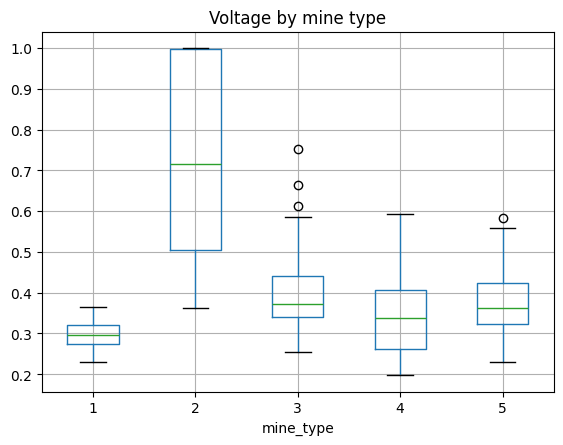

Best k: 3
Test accuracy: 0.432


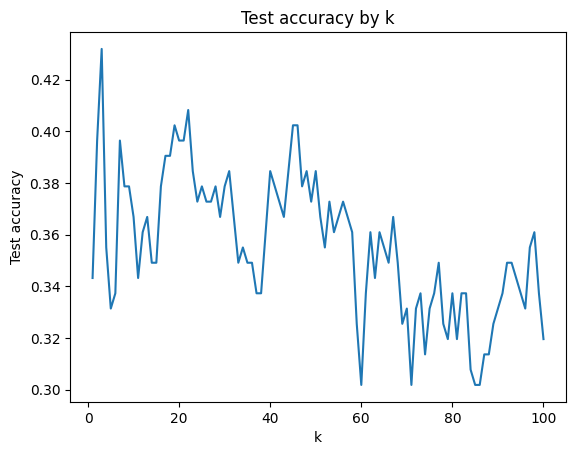

predicted   1   2   3  4  5
actual                     
1          24   0   6  3  3
2           1  29   2  2  1
3          15   3   8  1  6
4          10   4  10  8  1
5          14   1  12  1  4
Accuracy: 0.432


In [7]:
# Your Phase 1 solution to the problem goes here.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("data/land_mines.csv")
print(df.shape)
print(df.isna().sum())
print(df.describe())

print(df["mine_type"].value_counts().sort_index())

print(df.groupby("mine_type")[["voltage", "height", "soil"]].mean())

df.boxplot(column="voltage", by="mine_type")
plt.title("Voltage by mine type")
plt.suptitle("")
plt.show()

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=100, stratify=y)

k_values = list(range(1, 101))
accuracy = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    accuracy.append(model.score(X_test, y_test))

best_k = k_values[accuracy.index(max(accuracy))]
print("Best k:", best_k)
print("Test accuracy:", round(max(accuracy), 3))

plt.plot(k_values, accuracy)
plt.xlabel("k")
plt.ylabel("Test accuracy")
plt.title("Test accuracy by k")
plt.show()

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(pd.crosstab(y_test, y_pred, rownames=["actual"], colnames=["predicted"]))
print("Accuracy:", round((y_pred == y_test).mean(), 3))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** commit 3daa6a7ff14dfe05a6efcbc78a331d589bf9e481
- **AI tool and model used:** Claude Opus

### *Prompts used

1. Can you give me revisions that would make this code better. Do not worry about code optimization just provide changes that would make the code better at solving the task at hand.  also provide a brief justification for each revision.
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. **Standardize the features with a pipeline**

```python
   from sklearn.pipeline import make_pipeline
   from sklearn.preprocessing import StandardScaler

   model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
```

   *Justification:* k-NN predicts by distance, so a feature with a wider spread counts for more. The features run from 0 to 1, but most voltage values are packed between about 0.2 and 0.5, while height and soil are spread across the whole range. That gives voltage, the most informative feature, the least weight. Standardizing gives every feature the same spread. With k still chosen the original way, test accuracy rises from **43.2% to 49.1%**. The pipeline fits the scaler on training data only, so no information leaks from the test set.

2. **Choose k with cross-validation on the training set**

```python
   from sklearn.model_selection import cross_val_score

   accuracy = []
   for k in k_values:
       model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
       accuracy.append(cross_val_score(model, X_train, y_train, cv=5).mean())
   best_k = k_values[accuracy.index(max(accuracy))]
```

   *Justification:* The original code picks k by its test accuracy and then reports that same accuracy. That number is optimistic because the test set helped choose the model. Cross-validation picks k using only training data, and the test set is used once at the end. With revisions 1 and 2, CV picks **k = 1**, and the honest test accuracy is **43.8%**. One caveat: the CV curve is noisy (k = 1 scores 46.2% and k = 10 scores 45.6%), so the exact k isn't very stable.

3. **Report per-class precision and recall**

```python
   from sklearn.metrics import classification_report
   print(classification_report(y_test, y_pred))
```

   *Justification:* Q2.4 asks where the model is more or less accurate. This gives exact numbers for each class instead of reading them off the confusion table. With the revised model, recall is 0.77 for anti-tank, 0.53 for no mine, and 0.22–0.36 for the anti-personnel types.

4. **Count the mines predicted as "no mine"**

```python
   mines = y_test != 1
   missed = (mines & (y_pred == 1)).sum()
   print("Real mines predicted as 'no mine':", missed, "of", mines.sum())
```

   *Justification:* Q2.5 is about how costly the errors are, and a mine labeled "no mine" is the most dangerous error. Overall accuracy treats it the same as confusing two mine types. This line tracks it directly. It shows the biggest gain from the revisions: missed mines drop from **40 of 133 to 11 of 133**. In the original k = 3 model, most of those 40 came from three-way ties among the neighbors. scikit-learn breaks those ties toward the lowest class label, which is "no mine."



### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept  | This is a good point and is worthwhile to help with the task, especially since voltage is likely the most important feature |
| 2 | Accept  | This is good since it is a better approach to training than doing a strict split |
| 3 | Reject  | I find this addition a little bit unecessary. It could be helpful but not needed |
| 4 | Reject  | I like the proposed change here but again it is not necessary. This is more of a decision for someone who would be using the model but in this scenario it is not needed.|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
            voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


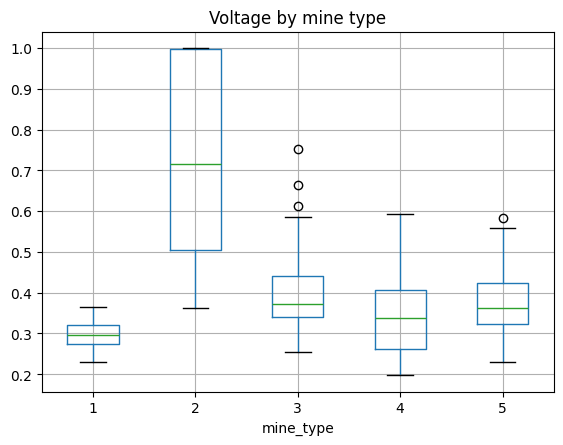

Best k: 1
Cross-validation accuracy: 0.462


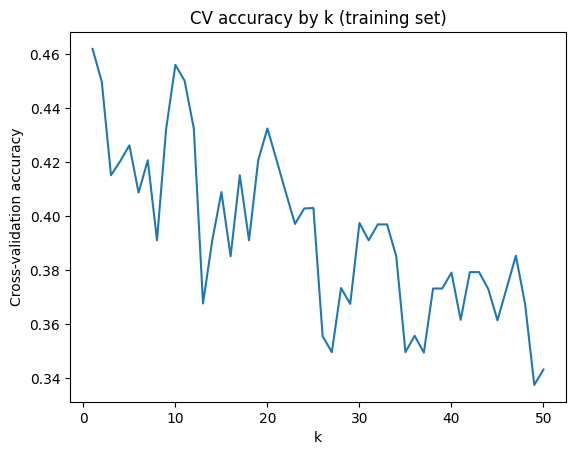

predicted   1   2   3   4   5
actual                       
1          19   0   8   3   6
2           0  27   0   7   1
3           3   2   9   9  10
4           4   3   8  12   6
5           4   0  16   5   7
Test accuracy: 0.438


In [9]:
# Your Phase 2 solution to the problem goes here.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/land_mines.csv")
print(df.shape)
print(df.isna().sum())
print(df.describe())

print(df["mine_type"].value_counts().sort_index())

print(df.groupby("mine_type")[["voltage", "height", "soil"]].mean())

df.boxplot(column="voltage", by="mine_type")
plt.title("Voltage by mine type")
plt.suptitle("")
plt.show()

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=100, stratify=y)

# Revision 1: standardize features inside a pipeline (scaler is fit on training data only)
# Revision 2: choose k with 5-fold cross-validation on the training set, not the test set
k_values = list(range(1, 51))
cv_accuracy = []
for k in k_values:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    cv_accuracy.append(cross_val_score(model, X_train, y_train, cv=5).mean())

best_k = k_values[cv_accuracy.index(max(cv_accuracy))]
print("Best k:", best_k)
print("Cross-validation accuracy:", round(max(cv_accuracy), 3))

plt.plot(k_values, cv_accuracy)
plt.xlabel("k")
plt.ylabel("Cross-validation accuracy")
plt.title("CV accuracy by k (training set)")
plt.show()

model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(pd.crosstab(y_test, y_pred, rownames=["actual"], colnames=["predicted"]))
print("Test accuracy:", round((y_pred == y_test).mean(), 3))


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The two revisions made the model more trustworthy more than they made it more accurate. Standardizing the features mattered because voltage was the most useful feature but had the smallest spread, so it counted for less in the distance calculation. Choosing k with cross-validation meant the test set was only used once, so the 43.8% accuracy is an honest number. Overall accuracy barely changed, but real mines predicted as "no mine" dropped from 40 to 11, which matters most here. The AI wasn't perfect, though. Its first version picked k using the test set, the same flaw it later pointed out, and cross-validation landed on k = 1, which overfits easily. I verified the results by rerunning the code myself and checking the confusion table by hand. I'm still concerned that accuracy is only 44%, types 3 and 5 get mixed up a lot, and 11 missed mines is too many to trust in the field.